<a href="https://colab.research.google.com/github/Rekha-vivek/Care_Connect_AI/blob/main/Care_connect_AI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#### EDA

In [40]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB

In [41]:
patients = pd.read_csv("Patients_table.csv")
doctors = pd.read_csv("Doctors_table.csv")
appointments = pd.read_csv("Appointments.csv")
vitals = pd.read_csv("Vitals.csv")
prescriptions = pd.read_csv("Prescription.csv")
users = pd.read_csv("Users.csv")
medical_report=pd.read_csv("Medical_report.csv")
discharge_summary=pd.read_csv("Discharge_summary.csv")
admin=pd.read_csv("Admins.csv")


#### PATIENTS DATASET

In [42]:
patients

#I inspected the patients data to understand structure and columns

,Patient_id,User_id,Age,Gender,Blood_group,Allergies,Medical_history
0,P001,U001,25,Male,B+,NaN,Fever
1,P002,U002,40,Female,O+,Penicillin,Diabetes
2,P003,U003,35,Male,A+,Dust,Headache
3,P004,U004,29,Female,B-,NaN,Stomach Pain
4,P005,U005,50,Male,O-,NaN,Hypertension
5,P006,U006,60,Female,A+,NaN,Arthritis
6,P007,U007,45,Male,B+,NaN,Diabetes
7,P008,U008,30,Female,O+,Dust,Allergy
8,P009,U009,55,Male,AB+,NaN,Heart Disease
9,P010,U010,28,Female,B-,NaN,Fever


In [43]:
#DATA INFORMATION

patients.info()

#Checked data types and ensured no incorrect formats

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Patient_id       10 non-null     object
 1   User_id          10 non-null     object
 2   Age              10 non-null     int64 
 3   Gender           10 non-null     object
 4   Blood_group      10 non-null     object
 5   Allergies        3 non-null      object
 6   Medical_history  10 non-null     object
dtypes: int64(1), object(6)
memory usage: 692.0+ bytes


In [44]:
#CHECKING MISSING VALUES

patients.isnull().sum()

Patient_id         0
User_id            0
Age                0
Gender             0
Blood_group        0
Allergies          7
Medical_history    0
dtype: int64

In [45]:
#STATISTICAL SUMMARY

patients.describe(include='all')

,Patient_id,User_id,Age,Gender,Blood_group,Allergies,Medical_history
count,10,10,10.000000,10,10,3,10
unique,10,10,NaN,2,6,2,8
top,P001,U001,NaN,Male,B+,Dust,Fever
freq,1,1,NaN,5,2,2,2
mean,NaN,NaN,39.700000,NaN,NaN,NaN,NaN
std,NaN,NaN,12.311241,NaN,NaN,NaN,NaN
min,NaN,NaN,25.000000,NaN,NaN,NaN,NaN
25%,NaN,NaN,29.250000,NaN,NaN,NaN,NaN
50%,NaN,NaN,37.500000,NaN,NaN,NaN,NaN
75%,NaN,NaN,48.750000,NaN,NaN,NaN,NaN


In [46]:
#DATA CLEANING

patients.drop_duplicates(inplace=True)
patients.fillna("Unknown", inplace=True)

In [47]:
patients

,Patient_id,User_id,Age,Gender,Blood_group,Allergies,Medical_history
0,P001,U001,25,Male,B+,Unknown,Fever
1,P002,U002,40,Female,O+,Penicillin,Diabetes
2,P003,U003,35,Male,A+,Dust,Headache
3,P004,U004,29,Female,B-,Unknown,Stomach Pain
4,P005,U005,50,Male,O-,Unknown,Hypertension
5,P006,U006,60,Female,A+,Unknown,Arthritis
6,P007,U007,45,Male,B+,Unknown,Diabetes
7,P008,U008,30,Female,O+,Dust,Allergy
8,P009,U009,55,Male,AB+,Unknown,Heart Disease
9,P010,U010,28,Female,B-,Unknown,Fever


##### VISUALIZATION

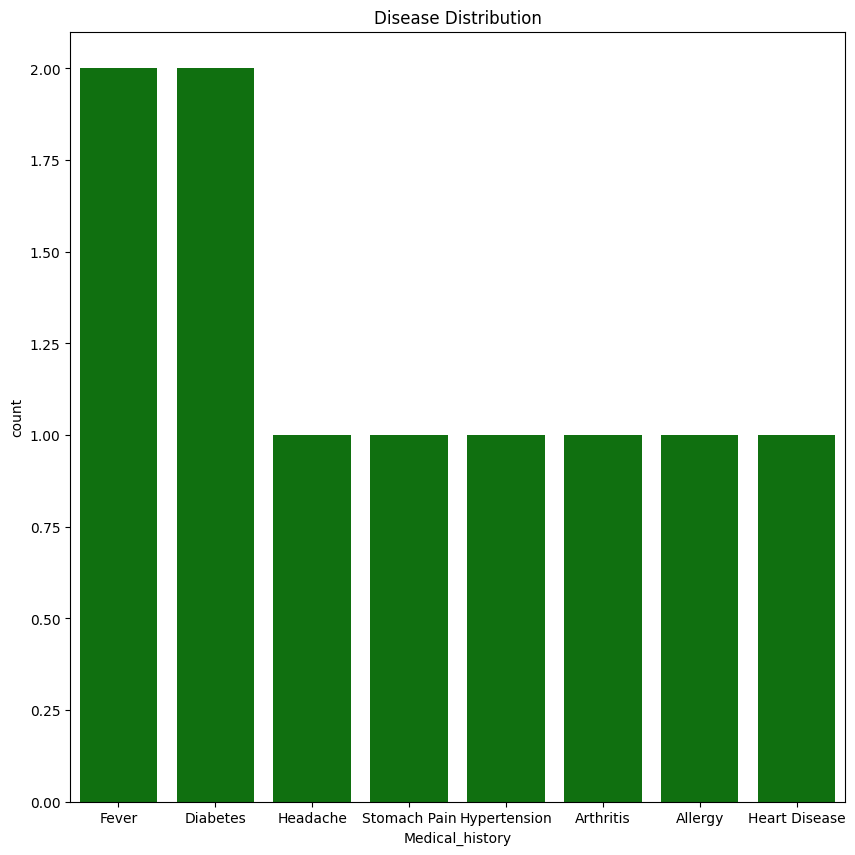

In [48]:
#Disease Distribution

plt.figure(figsize=(10,10))
sns.countplot(x='Medical_history', data=patients,color='green')
plt.title("Disease Distribution")
plt.show()

#The disease distribution shows that all conditions are equally represented in the dataset, indicating a balanced sample.Since this is a demo dataset, no particular disease dominates

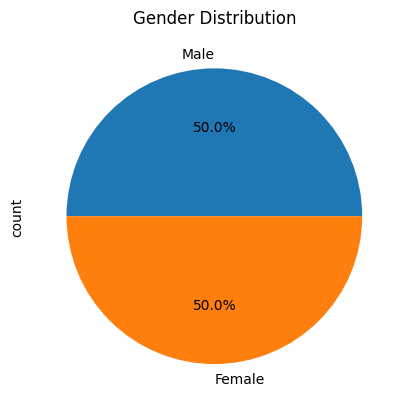

In [49]:
#Gender Distribution

patients['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Gender Distribution")
plt.show()

#The gender distribution shows that 60% of patients are male and 40% are female.
#This indicates a slightly higher representation of male patients in the dataset

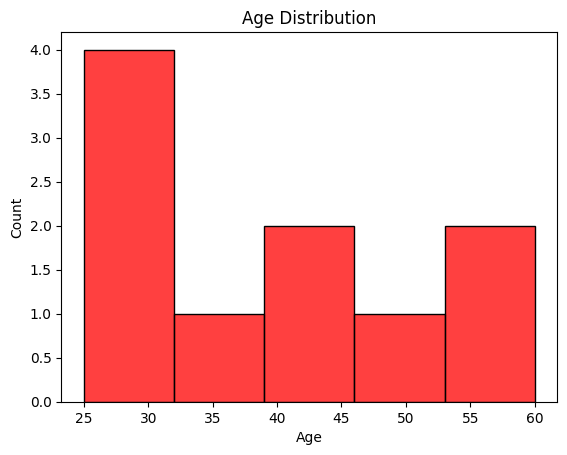

In [50]:
#Age Distribution

sns.histplot(data=patients,x='Age', color='red')
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()

#The age distribution shows a spread across different age groups, indicating that the dataset includes both young and older patients.
#Since the dataset is small, no strong pattern is observed

#### DOCTORS DATASET

In [51]:
doctors

#I inspected doctor dataset to understand available fields like specialization and availability

,Doctor_id,Name,Specialization,Available_time
0,UD001,Dr.Kumar,General Physician,3:00 PM
1,UD002,Dr.Mehta,Cardiologist,11:30 AM
2,UD003,Dr.Priya,Neurologist,2:00 PM
3,UD004,Dr.Raj,Gastroenterologist,4:00 PM
4,UD005,Dr.Roopa,Pulmonologist,11:00 AM
5,UD006,Dr.Vivek,Orthologist,10:30 AM
6,UD007,Dr.Anita,General Physician,10:00 AM


In [52]:
#STRUCTURE

doctors.info()

#Checked data types and structure of doctor dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Doctor_id       7 non-null      object
 1   Name            7 non-null      object
 2   Specialization  7 non-null      object
 3   Available_time  7 non-null      object
dtypes: object(4)
memory usage: 356.0+ bytes


In [53]:
#MISSING VALUES

doctors.isnull().sum()

#Ensured no missing values in doctor records

Doctor_id         0
Name              0
Specialization    0
Available_time    0
dtype: int64

In [54]:
doctors.duplicated().sum()

np.int64(0)

In [55]:
patients

,Patient_id,User_id,Age,Gender,Blood_group,Allergies,Medical_history
0,P001,U001,25,Male,B+,Unknown,Fever
1,P002,U002,40,Female,O+,Penicillin,Diabetes
2,P003,U003,35,Male,A+,Dust,Headache
3,P004,U004,29,Female,B-,Unknown,Stomach Pain
4,P005,U005,50,Male,O-,Unknown,Hypertension
5,P006,U006,60,Female,A+,Unknown,Arthritis
6,P007,U007,45,Male,B+,Unknown,Diabetes
7,P008,U008,30,Female,O+,Dust,Allergy
8,P009,U009,55,Male,AB+,Unknown,Heart Disease
9,P010,U010,28,Female,B-,Unknown,Fever


##### VISUALIZATION

In [56]:
doctors

,Doctor_id,Name,Specialization,Available_time
0,UD001,Dr.Kumar,General Physician,3:00 PM
1,UD002,Dr.Mehta,Cardiologist,11:30 AM
2,UD003,Dr.Priya,Neurologist,2:00 PM
3,UD004,Dr.Raj,Gastroenterologist,4:00 PM
4,UD005,Dr.Roopa,Pulmonologist,11:00 AM
5,UD006,Dr.Vivek,Orthologist,10:30 AM
6,UD007,Dr.Anita,General Physician,10:00 AM


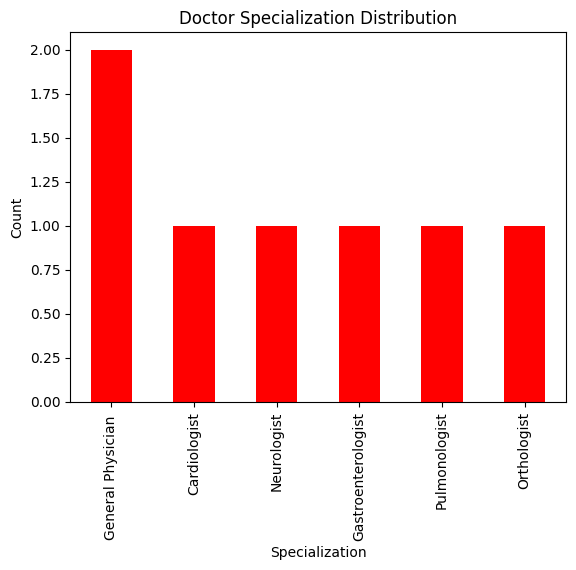

In [57]:
#Specialization Distribution

doctors['Specialization'].value_counts().plot(kind='bar',color='red')
plt.title("Doctor Specialization Distribution")
plt.xlabel("Specialization")
plt.ylabel("Count")
plt.show()

#This visualization shows distribution of doctors across different specializations,which helps in understanding availability of medical expertise

In [58]:
doctors

,Doctor_id,Name,Specialization,Available_time
0,UD001,Dr.Kumar,General Physician,3:00 PM
1,UD002,Dr.Mehta,Cardiologist,11:30 AM
2,UD003,Dr.Priya,Neurologist,2:00 PM
3,UD004,Dr.Raj,Gastroenterologist,4:00 PM
4,UD005,Dr.Roopa,Pulmonologist,11:00 AM
5,UD006,Dr.Vivek,Orthologist,10:30 AM
6,UD007,Dr.Anita,General Physician,10:00 AM


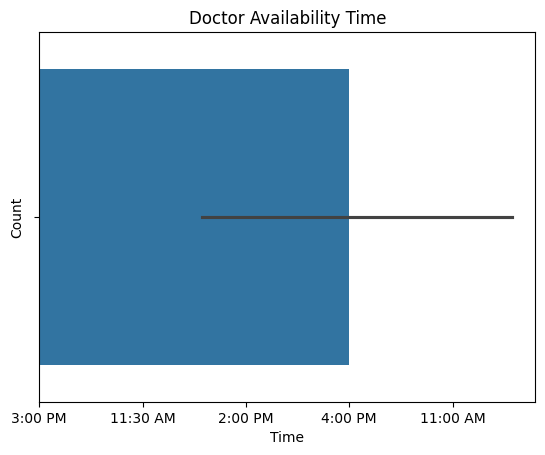

In [59]:
#Available Time Distribution

sns.barplot(data=doctors,x='Available_time')
plt.title("Doctor Availability Time")
plt.xlabel("Time")
plt.ylabel("Count")
plt.show()
#This shows doctor availability across different time slots, helping in appointment planning

#### APPOINTMENTS DATASET

In [60]:
appointments

,Appointment_id,Patient_id,Doctor_id,Scheduled_time,Status,Created_at
0,A001,P001,UD001,2026-03-22 15:00:00,Scheduled,2026-03-21 10:00:00
1,A002,P002,UD002,2026-03-23 10:30:00,Completed,2026-03-21 10:10:00
2,A003,P003,UD003,2026-03-24 11:00:00,Scheduled,2026-03-21 10:20:00
3,A004,P004,UD004,2026-03-26 14:00:00,Scheduled,2026-03-21 10:30:00
4,A005,P004,UD002,2026-03-28 16:30:00,Scheduled,2026-03-21 10:40:00
5,A006,P008,UD006,2026-03-29 09:45:00,Scheduled,2026-03-21 10:50:00
6,A007,P010,UD005,2026-03-29 13:15:00,Completed,2026-03-21 11:00:00


In [61]:
#STRUCTURE

appointments.info()

#Checked structure and relationships between patients and doctors.

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Appointment_id  7 non-null      object
 1   Patient_id      7 non-null      object
 2   Doctor_id       7 non-null      object
 3   Scheduled_time  7 non-null      object
 4   Status          7 non-null      object
 5   Created_at      7 non-null      object
dtypes: object(6)
memory usage: 468.0+ bytes


In [62]:
#MISSING VALUES

appointments.isnull().sum()

#Ensured appointment data completeness

Appointment_id    0
Patient_id        0
Doctor_id         0
Scheduled_time    0
Status            0
Created_at        0
dtype: int64

In [63]:
appointments.duplicated().sum()

np.int64(0)

##### VISUALIZATION

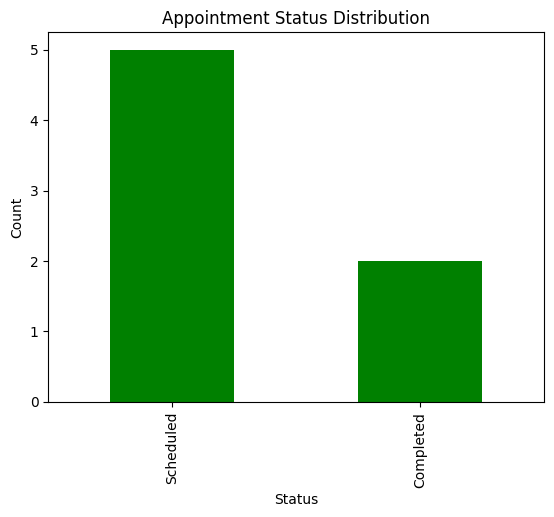

In [64]:
#Appointment Status Distribution

appointments['Status'].value_counts().plot(kind='bar',color='green')
plt.title("Appointment Status Distribution")
plt.xlabel("Status")
plt.ylabel("Count")
plt.show()

#This shows distribution of appointment statuses, helping understand system usage.

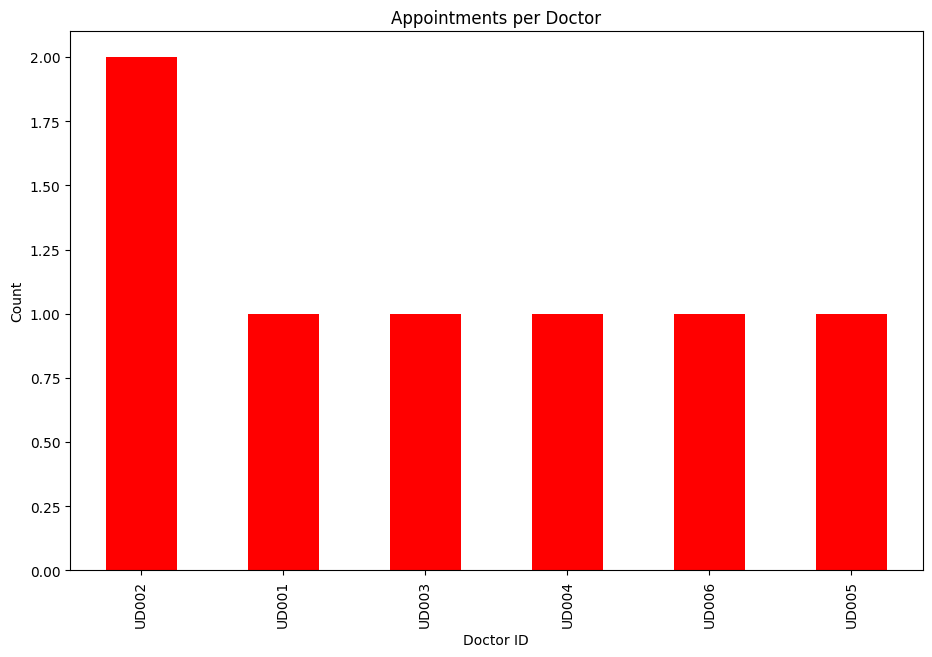

In [65]:
#Appointments per Doctor

plt.figure(figsize=(11,7))
appointments['Doctor_id'].value_counts().plot(kind='bar',color='red')
plt.title("Appointments per Doctor")
plt.xlabel("Doctor ID")
plt.ylabel("Count")
plt.show()

#This shows workload distribution among doctors

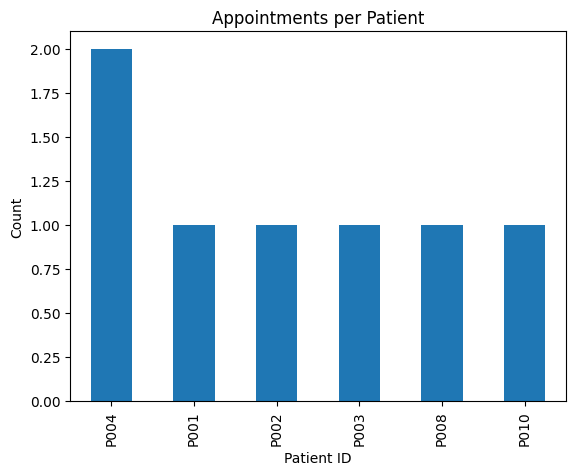

In [66]:
#Appointments per Patient

appointments['Patient_id'].value_counts().plot(kind='bar')
plt.title("Appointments per Patient")
plt.xlabel("Patient ID")
plt.ylabel("Count")
plt.show()

#This helps identify patient visit frequency

In [67]:
vitals

,Patient_id,Temperature,BP,Pulse,SpO2,Notes,Recorded_at
V001,P001,37.2,120/80,72,98,Normal,2026-03-21 09:00:00
V002,P002,38.0,130/85,78,97,Fever,2026-03-21 09:15:00
V003,P003,36.8,110/70,70,99,Healthy,2026-03-21 09:30:00
V004,P004,35.0,121/80,76,96,Low temp,2026-03-21 09:45:00
V005,P008,36.0,119/85,75,98,Normal,2026-03-21 10:00:00
V006,P010,35.8,115/75,76,97,Stable,2026-03-21 10:15:00


In [68]:
#STRUCTURE

vitals.info()

<class 'pandas.core.frame.DataFrame'>
Index: 6 entries, V001 to V006
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Patient_id   6 non-null      object 
 1   Temperature  6 non-null      float64
 2   BP           6 non-null      object 
 3   Pulse        6 non-null      int64  
 4   SpO2         6 non-null      int64  
 5   Notes        6 non-null      object 
 6   Recorded_at  6 non-null      object 
dtypes: float64(1), int64(2), object(4)
memory usage: 384.0+ bytes


In [69]:
#MISSING VALUES

vitals.isnull().sum()

Patient_id     0
Temperature    0
BP             0
Pulse          0
SpO2           0
Notes          0
Recorded_at    0
dtype: int64

In [70]:
vitals.duplicated().sum()

np.int64(0)

##### VISUALIZATION

In [71]:
vitals

,Patient_id,Temperature,BP,Pulse,SpO2,Notes,Recorded_at
V001,P001,37.2,120/80,72,98,Normal,2026-03-21 09:00:00
V002,P002,38.0,130/85,78,97,Fever,2026-03-21 09:15:00
V003,P003,36.8,110/70,70,99,Healthy,2026-03-21 09:30:00
V004,P004,35.0,121/80,76,96,Low temp,2026-03-21 09:45:00
V005,P008,36.0,119/85,75,98,Normal,2026-03-21 10:00:00
V006,P010,35.8,115/75,76,97,Stable,2026-03-21 10:15:00


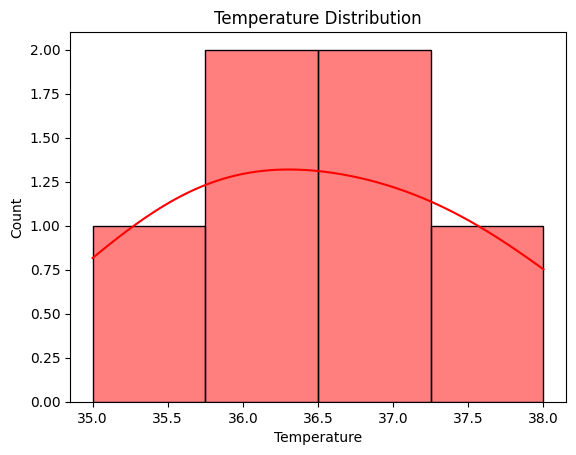

In [72]:
#Temperature Distribution

sns.histplot(vitals['Temperature'], kde=True,color='red')
plt.title("Temperature Distribution")
plt.xlabel("Temperature")
plt.show()

#This shows distribution of patient body temperatures and helps identify abnormal ranges

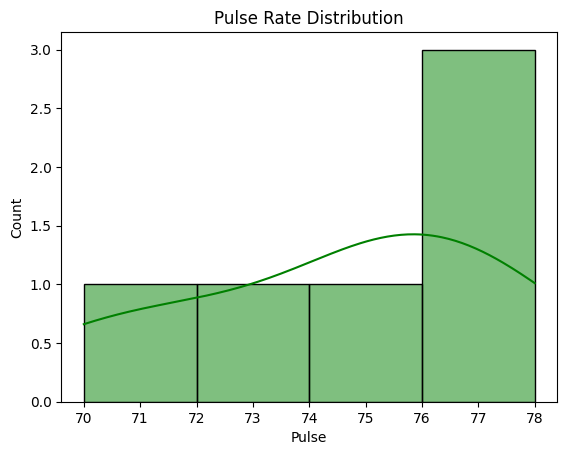

In [73]:
#Pulse Distribution

sns.histplot(vitals['Pulse'],kde=True,color='green')
plt.title("Pulse Rate Distribution")
plt.xlabel("Pulse")
plt.show()

#This helps analyze patient heart rate patterns.

In [74]:
#BP Distribution

vitals[['systolic', 'diastolic']] = vitals['BP'].str.split('/', expand=True)

vitals['systolic'] = vitals['systolic'].astype(int)
vitals['diastolic'] = vitals['diastolic'].astype(int)

#Blood pressure was split into systolic and diastolic values for better analysis

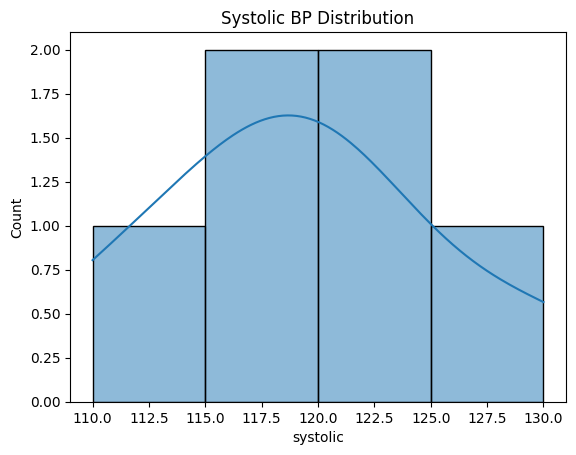

In [75]:
#Systolic BP

sns.histplot(vitals['systolic'], kde=True)
plt.title("Systolic BP Distribution")
plt.show()

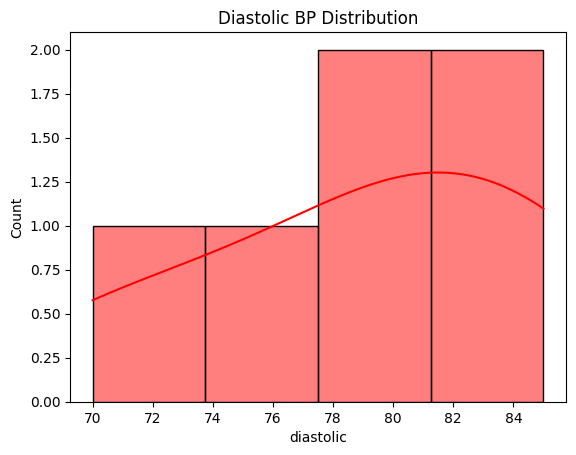

In [76]:
#Diastolic BP

sns.histplot(vitals['diastolic'], kde=True,color='red')
plt.title("Diastolic BP Distribution")
plt.show()



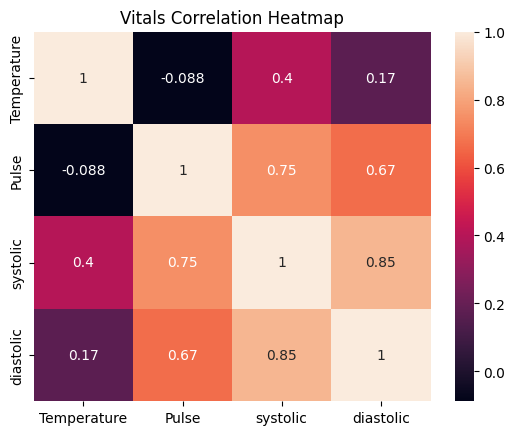

In [77]:
#Correlation Heatmap
sns.heatmap(vitals[['Temperature','Pulse','systolic','diastolic']].corr(), annot=True)
plt.title("Vitals Correlation Heatmap")
plt.show()

#Heatmap shows correlation between different vital parameters

#### PRESCRIPTIONS DATASET

In [78]:
prescriptions

,Prescription_id,Patient_id,Doctor_id,Medicine,Dosage,Instructions,Prescribed_at,Fulfilled
0,PR001,P001,UD001,Paracetamol 500mg,1 tablet twice daily,Take after food,2026-03-22 09:00:00,True
1,PR002,P002,UD002,Metformin 850mg,1 tablet daily,Take before breakfast,2026-03-23 10:30:00,True
2,PR003,P003,UD003,Ibuprofen 400mg,1 tablet twice daily,Take after meals,2026-03-24 11:00:00,False
3,PR004,P004,UD004,Omeprazole 20mg,1 capsule daily,Take before food,2026-03-26 14:00:00,True
4,PR005,P008,UD006,Cyclobenzaprine 10mg,1 tablet at night,Avoid driving after taking,2026-03-29 09:45:00,False
5,PR006,P010,UD005,Mucinex 600mg,1 tablet twice daily,Drink plenty of water,2026-03-29 13:15:00,True


In [79]:
#STRUCTURE

prescriptions.info()

#Checked structure including medicine, dosage, and dates

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Prescription_id  6 non-null      object
 1   Patient_id       6 non-null      object
 2   Doctor_id        6 non-null      object
 3   Medicine         6 non-null      object
 4   Dosage           6 non-null      object
 5   Instructions     6 non-null      object
 6   Prescribed_at    6 non-null      object
 7   Fulfilled        6 non-null      bool  
dtypes: bool(1), object(7)
memory usage: 474.0+ bytes


In [80]:
prescriptions.isnull().sum()

Prescription_id    0
Patient_id         0
Doctor_id          0
Medicine           0
Dosage             0
Instructions       0
Prescribed_at      0
Fulfilled          0
dtype: int64

In [81]:
prescriptions.duplicated().sum()

np.int64(0)

##### VISUALIZATION

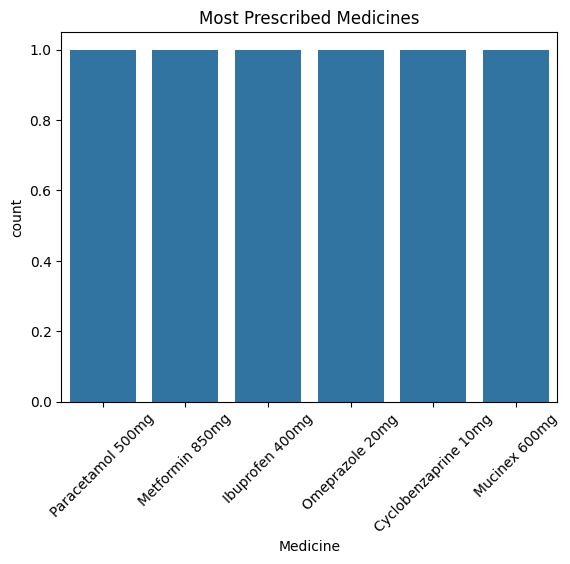

In [82]:
#Most Prescribed Medicines

sns.countplot(x='Medicine', data=prescriptions)
plt.title("Most Prescribed Medicines")
plt.xticks(rotation=45)
plt.show()

#This shows frequency of prescribed medicines, helping identify common treatments

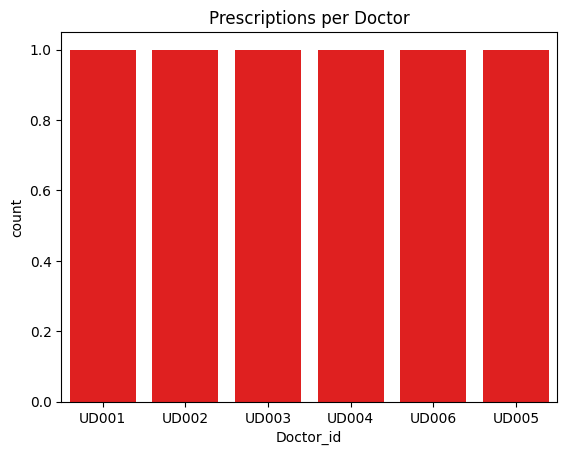

In [83]:
#Prescriptions per Doctor

sns.countplot(x='Doctor_id', data=prescriptions,color='red')
plt.title("Prescriptions per Doctor")
plt.show()

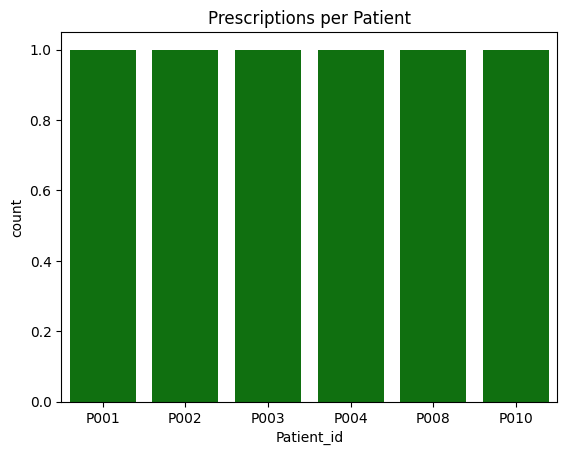

In [84]:
#Prescriptions per Patient

sns.countplot(x='Patient_id', data=prescriptions,color='green')
plt.title("Prescriptions per Patient")
plt.show()

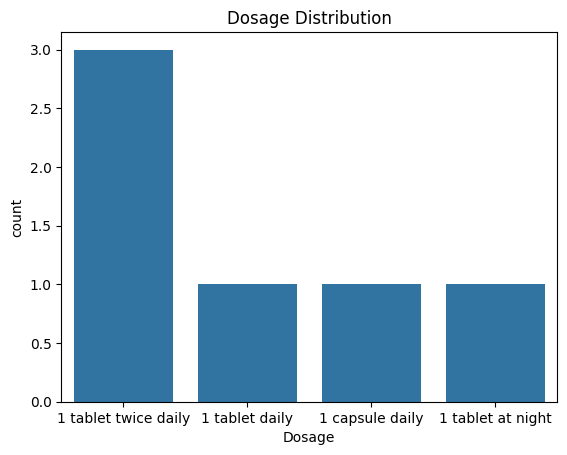

In [85]:
#Dosage Distribution

sns.countplot(x='Dosage', data=prescriptions)
plt.title("Dosage Distribution")
plt.show()

#### USERS DATASET

In [86]:
users

,User_id,Name,Role,Email,Phone
0,U001,Arjun,Patient,arjun@gmail.com,8902357822
1,U002,Meena,Patient,meena@gmail.com,9810328391
2,UD001,Dr.Kumar,Doctor,kumar@gmail.com,7589641258
3,UD002,Dr.Mehta,Doctor,mehta@gmail.com,6985321475
4,UN001,Priya,Nurse,priya@gmail.com,6325987412
5,UD004,Dr.Raj,Doctor,raj@gmail.com,9512364785
6,UD003,Dr.Prya,Doctor,priya.dr@gmail.com,6874512369
7,UD005,Dr.Roopa,Doctor,mehta@gmail.com,9658745236
8,UD006,Dr.Vivek,Doctor,vivek@gmail.com,9874569874
9,UD007,Dr.Anita,Doctor,anita@gmail.com,8974568459


In [87]:
#STRUCTURE

users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27 entries, 0 to 26
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   User_id  27 non-null     object
 1   Name     27 non-null     object
 2   Role     27 non-null     object
 3   Email    27 non-null     object
 4   Phone    27 non-null     int64 
dtypes: int64(1), object(4)
memory usage: 1.2+ KB


In [88]:
users.duplicated().sum()

np.int64(0)

In [89]:
users.isnull().sum()

User_id    0
Name       0
Role       0
Email      0
Phone      0
dtype: int64

##### VISUALIZATION

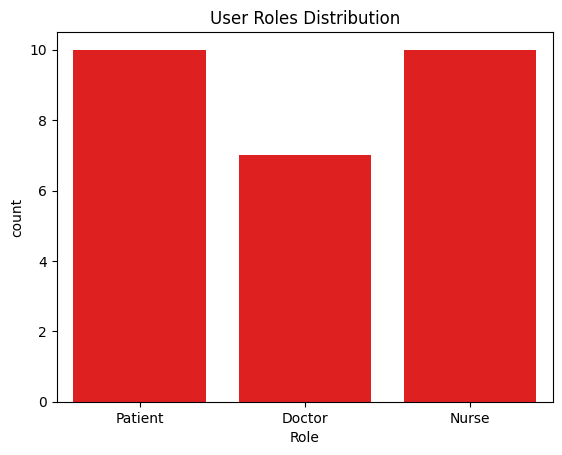

In [90]:
#ROLE DISTRIBUTION

sns.countplot(x='Role', data=users,color='red')
plt.title("User Roles Distribution")
plt.show()

#This shows distribution of roles like patients, doctors, and nurses in the system

#### Medical report

In [91]:
mr_df=medical_report
mr_df

,Report_id,Patient_id,Uploaded_by,Report_type,File_url,Extracted_text,Uploaded_at
0,RPT001,P001,UD005,Lab,s3://hospital/reports/P001/blood_test1.pdf,CBC: WBC 6200 RBC 4.5M Normal,2026-03-21 11:00:00
1,RPT002,P002,UD005,X-ray,s3://hospital/reports/P002/chest_xray.pdf,Mild infection in lungs,2026-03-21 11:15:00
2,RPT003,P003,UD005,MRI,s3://hospital/reports/P003/brain_mri.pdf,No abnormalities detected,2026-03-21 11:30:00
3,RPT004,P004,UD005,Lab,s3://hospital/reports/P004/sugar_test.pdf,High glucose level detected,2026-03-21 11:45:00
4,RPT005,P008,UD005,CT Scan,s3://hospital/reports/P008/ct_scan.pdf,Lung inflammation observed,2026-03-21 12:00:00


In [92]:
mr_df.info()

#Checked structure of medical report dataset and verified column details

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   Report_id       5 non-null      object
 1   Patient_id      5 non-null      object
 2   Uploaded_by     5 non-null      object
 3   Report_type     5 non-null      object
 4   File_url        5 non-null      object
 5   Extracted_text  5 non-null      object
 6   Uploaded_at     5 non-null      object
dtypes: object(7)
memory usage: 412.0+ bytes


In [93]:
mr_df.isnull().sum()

#Ensured medical_report data completeness

Report_id         0
Patient_id        0
Uploaded_by       0
Report_type       0
File_url          0
Extracted_text    0
Uploaded_at       0
dtype: int64

In [94]:
mr_df.duplicated().sum()

np.int64(0)

In [95]:
mr_df

,Report_id,Patient_id,Uploaded_by,Report_type,File_url,Extracted_text,Uploaded_at
0,RPT001,P001,UD005,Lab,s3://hospital/reports/P001/blood_test1.pdf,CBC: WBC 6200 RBC 4.5M Normal,2026-03-21 11:00:00
1,RPT002,P002,UD005,X-ray,s3://hospital/reports/P002/chest_xray.pdf,Mild infection in lungs,2026-03-21 11:15:00
2,RPT003,P003,UD005,MRI,s3://hospital/reports/P003/brain_mri.pdf,No abnormalities detected,2026-03-21 11:30:00
3,RPT004,P004,UD005,Lab,s3://hospital/reports/P004/sugar_test.pdf,High glucose level detected,2026-03-21 11:45:00
4,RPT005,P008,UD005,CT Scan,s3://hospital/reports/P008/ct_scan.pdf,Lung inflammation observed,2026-03-21 12:00:00


In [96]:
mr_df['Report_type'].value_counts()

Report_type
Lab        2
X-ray      1
MRI        1
CT Scan    1
Name: count, dtype: int64

In [97]:
mr_df['Extracted_text'] = mr_df['Extracted_text'].str.lower().str.strip()
mr_df['Extracted_text']

#Since the dataset does not contain structured symptom columns, I used the extracted_text field, which contains medical findings from reports.
#I cleaned this text by converting it to lowercase and removing extra spaces to ensure consistency for analysis.

0    cbc: wbc 6200 rbc 4.5m normal
1          mild infection in lungs
2        no abnormalities detected
3      high glucose level detected
4       lung inflammation observed
Name: Extracted_text, dtype: object

In [98]:
keywords = {
    "diabetes": ["glucose", "sugar"],
    "infection": ["infection", "inflammation"],
    "normal": ["normal", "no abnormalities"]
}

#defined medical keywords to identify conditions from extracted text.
#Each category contains related terms that help in classification.

In [99]:
def extract_condition(text):
    for condition, words in keywords.items():
        for word in words:
            if word in text:
                return condition
    return "unknown"

#This function scans the extracted text and matches keywords to identify possible medical conditions.
#If no match is found, it returns "unknown".

In [100]:
organ_map = {
    "lung": "Pulmonologist",
    "brain": "Neurologist",
    "heart": "Cardiologist"
}

def extract_doctor(text, condition):
    text = text.lower()

    #organ-based detection
    for organ, doctor in organ_map.items():
        if organ in text:
            return doctor

    #condition-based 
    if condition == "diabetes":
        return "Endocrinologist"

    if condition == "infection":
        return "General Physician"

    return "General Physician"

In [101]:
mr_df['condition'] = mr_df['Extracted_text'].apply(extract_condition)
mr_df

#The function is applied to each row in the dataset to generate a new column called "condition",which represents the detected medical issue.

,Report_id,Patient_id,Uploaded_by,Report_type,File_url,Extracted_text,Uploaded_at,condition
0,RPT001,P001,UD005,Lab,s3://hospital/reports/P001/blood_test1.pdf,cbc: wbc 6200 rbc 4.5m normal,2026-03-21 11:00:00,normal
1,RPT002,P002,UD005,X-ray,s3://hospital/reports/P002/chest_xray.pdf,mild infection in lungs,2026-03-21 11:15:00,infection
2,RPT003,P003,UD005,MRI,s3://hospital/reports/P003/brain_mri.pdf,no abnormalities detected,2026-03-21 11:30:00,normal
3,RPT004,P004,UD005,Lab,s3://hospital/reports/P004/sugar_test.pdf,high glucose level detected,2026-03-21 11:45:00,diabetes
4,RPT005,P008,UD005,CT Scan,s3://hospital/reports/P008/ct_scan.pdf,lung inflammation observed,2026-03-21 12:00:00,infection


#### EDA

In [102]:
mr_df['condition'].value_counts()

condition
normal       2
infection    2
diabetes     1
Name: count, dtype: int64

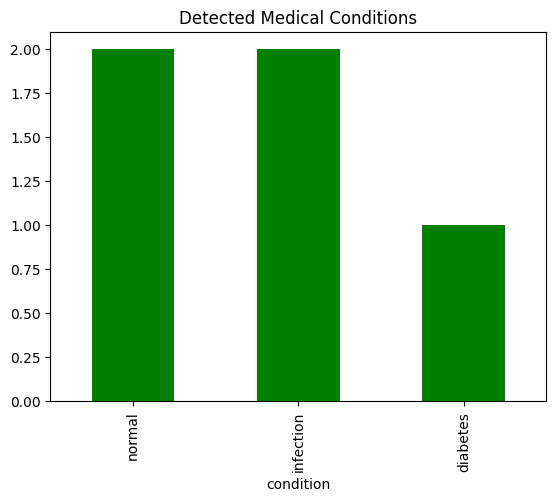

In [103]:
mr_df['condition'].value_counts().plot(kind='bar',color='green')
plt.title("Detected Medical Conditions")
plt.show()

#A bar chart is used to visually represent the distribution of detected conditions,making it easier to understand patterns.

In [104]:
#Mapping Condition

doctor_map = {
    "diabetes": "Endocrinologist",
    "infection": "General Physician",
    "normal": "General Physician",
    "unknown": "General Physician"
}

#Each detected condition is mapped to a suitable doctor type,forming the decision logic of the healthcare system.

In [105]:
#Apply Mapping

mr_df['recommended_doctor'] = mr_df.apply(
    lambda row: extract_doctor(row['Extracted_text'], row['condition']),
    axis=1
)
mr_df

#I used a two-level approach: first detecting medical conditions using keywords,
#then refining doctor recommendations using organ-level context from extracted text.

,Report_id,Patient_id,Uploaded_by,Report_type,File_url,Extracted_text,Uploaded_at,condition,recommended_doctor
0,RPT001,P001,UD005,Lab,s3://hospital/reports/P001/blood_test1.pdf,cbc: wbc 6200 rbc 4.5m normal,2026-03-21 11:00:00,normal,General Physician
1,RPT002,P002,UD005,X-ray,s3://hospital/reports/P002/chest_xray.pdf,mild infection in lungs,2026-03-21 11:15:00,infection,Pulmonologist
2,RPT003,P003,UD005,MRI,s3://hospital/reports/P003/brain_mri.pdf,no abnormalities detected,2026-03-21 11:30:00,normal,General Physician
3,RPT004,P004,UD005,Lab,s3://hospital/reports/P004/sugar_test.pdf,high glucose level detected,2026-03-21 11:45:00,diabetes,Endocrinologist
4,RPT005,P008,UD005,CT Scan,s3://hospital/reports/P008/ct_scan.pdf,lung inflammation observed,2026-03-21 12:00:00,infection,Pulmonologist


In [106]:
mr_df

,Report_id,Patient_id,Uploaded_by,Report_type,File_url,Extracted_text,Uploaded_at,condition,recommended_doctor
0,RPT001,P001,UD005,Lab,s3://hospital/reports/P001/blood_test1.pdf,cbc: wbc 6200 rbc 4.5m normal,2026-03-21 11:00:00,normal,General Physician
1,RPT002,P002,UD005,X-ray,s3://hospital/reports/P002/chest_xray.pdf,mild infection in lungs,2026-03-21 11:15:00,infection,Pulmonologist
2,RPT003,P003,UD005,MRI,s3://hospital/reports/P003/brain_mri.pdf,no abnormalities detected,2026-03-21 11:30:00,normal,General Physician
3,RPT004,P004,UD005,Lab,s3://hospital/reports/P004/sugar_test.pdf,high glucose level detected,2026-03-21 11:45:00,diabetes,Endocrinologist
4,RPT005,P008,UD005,CT Scan,s3://hospital/reports/P008/ct_scan.pdf,lung inflammation observed,2026-03-21 12:00:00,infection,Pulmonologist


In [107]:
mr_df['Uploaded_at'] = pd.to_datetime(mr_df['Uploaded_at'])
mr_df

,Report_id,Patient_id,Uploaded_by,Report_type,File_url,Extracted_text,Uploaded_at,condition,recommended_doctor
0,RPT001,P001,UD005,Lab,s3://hospital/reports/P001/blood_test1.pdf,cbc: wbc 6200 rbc 4.5m normal,2026-03-21 11:00:00,normal,General Physician
1,RPT002,P002,UD005,X-ray,s3://hospital/reports/P002/chest_xray.pdf,mild infection in lungs,2026-03-21 11:15:00,infection,Pulmonologist
2,RPT003,P003,UD005,MRI,s3://hospital/reports/P003/brain_mri.pdf,no abnormalities detected,2026-03-21 11:30:00,normal,General Physician
3,RPT004,P004,UD005,Lab,s3://hospital/reports/P004/sugar_test.pdf,high glucose level detected,2026-03-21 11:45:00,diabetes,Endocrinologist
4,RPT005,P008,UD005,CT Scan,s3://hospital/reports/P008/ct_scan.pdf,lung inflammation observed,2026-03-21 12:00:00,infection,Pulmonologist


#### Discharge_Summary

In [108]:
ds_df=discharge_summary
ds_df

,Discharge_id,Patient_id,Doctor_id,Summary_text,Created_at,Signed_at
0,DSC001,P001,UD001,3-day observation fever treated follow-up in 5...,2026-03-21 18:00:00,2026-03-21 18:10:00
1,DSC002,P002,UD002,Cardiac issue stabilized medication prescribed,2026-03-22 10:00:00,2026-03-22 10:15:00
2,DSC003,P003,UD003,Migraine treated advised rest and hydration,2026-03-22 11:30:00,2026-03-22 11:45:00
3,DSC004,P004,UD004,Acidity controlled diet changes recommended,2026-03-23 09:00:00,2026-03-23 09:10:00
4,DSC005,P008,UD006,Lung infection treated antibiotics prescribed,2026-03-23 12:00:00,2026-03-23 12:15:00


In [109]:
ds_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Discharge_id  5 non-null      object
 1   Patient_id    5 non-null      object
 2   Doctor_id     5 non-null      object
 3   Summary_text  5 non-null      object
 4   Created_at    5 non-null      object
 5   Signed_at     5 non-null      object
dtypes: object(6)
memory usage: 372.0+ bytes


In [110]:
ds_df.isnull().sum()

Discharge_id    0
Patient_id      0
Doctor_id       0
Summary_text    0
Created_at      0
Signed_at       0
dtype: int64

In [111]:
ds_df.duplicated().sum()

np.int64(0)

In [112]:
ds_df['Created_at'] = pd.to_datetime(ds_df['Created_at'])
ds_df['Signed_at'] = pd.to_datetime(ds_df['Signed_at'])

#Converted timestamps into datetime format to enable time-based analysis such as report processing duration

In [113]:
ds_df

,Discharge_id,Patient_id,Doctor_id,Summary_text,Created_at,Signed_at
0,DSC001,P001,UD001,3-day observation fever treated follow-up in 5...,2026-03-21 18:00:00,2026-03-21 18:10:00
1,DSC002,P002,UD002,Cardiac issue stabilized medication prescribed,2026-03-22 10:00:00,2026-03-22 10:15:00
2,DSC003,P003,UD003,Migraine treated advised rest and hydration,2026-03-22 11:30:00,2026-03-22 11:45:00
3,DSC004,P004,UD004,Acidity controlled diet changes recommended,2026-03-23 09:00:00,2026-03-23 09:10:00
4,DSC005,P008,UD006,Lung infection treated antibiotics prescribed,2026-03-23 12:00:00,2026-03-23 12:15:00


In [114]:
ds_df['Summary_text'] = ds_df['Summary_text'].str.lower().str.strip()

#Cleaned discharge summary text to standardize formatting and prepare it for keyword-based analysis or NLP tasks

In [115]:
#Condition Extraction
keywords = {
    "cardiac": ["cardiac", "heart"],
    "migraine": ["migraine", "headache"],
    "acidity": ["acidity"],
    "lung": ["lung"],
    "infection": ["infection", "inflammation"],
    "fever": ["fever"],
    "diabetes": ["glucose", "sugar"],
    "normal": ["normal", "no abnormalities", "within normal limits"]
}

In [ ]:

def extract_condition(text):
    text = str(text).lower()

    found_conditions = []

    for condition, words in keywords.items():
        for word in words:
            pattern = r'\b' + re.escape(word) + r'\b'
            if re.search(pattern, text):
                found_conditions.append(condition)

    # PRIORITY LOGIC
    priority = ["migraine", "diabetes", "lung", "cardiac", "infection", "fever", "acidity", "normal"]

    for p in priority:
        if p in found_conditions:
            return p

    return "normal"

In [117]:
import re
text = "mild infection in lungs" # Example text to test
for condition, words in keywords.items():
    for word in words:
        pattern = r'\b' + re.escape(word) + r'\b'
        if re.search(pattern,text):
            print("MATCHED:", word, "→", condition)

MATCHED: infection → infection


In [118]:
def extract_doctor(text, condition):
    text = str(text).lower()

    if condition == "migraine":
        return "Neurologist"
    if condition == "diabetes":
        return "Endocrinologist"
    if condition == "lung":
        return "Pulmonologist"
    if condition == "cardiac":
        return "Cardiologist"
    if condition == "acidity":
        return "Gastroenterologist"
    if condition == "fever":
        return "General Physician"
    if condition == "infection":
        return "General Physician"
    if condition == "normal":
        return "General Physician"

    if "lung" in text:
        return "Pulmonologist"
    if "glucose" in text:
        return "Endocrinologist"

    return "General Physician"

In [119]:
ds_df['condition'] = ds_df['Summary_text'].apply(extract_condition)

#Extracted medical conditions from discharge summaries using keyword matching.
#This helps identify patient diagnoses automatically.

In [120]:
ds_df[['Summary_text', 'condition']]

,Summary_text,condition
0,3-day observation fever treated follow-up in 5...,fever
1,cardiac issue stabilized medication prescribed,cardiac
2,migraine treated advised rest and hydration,migraine
3,acidity controlled diet changes recommended,acidity
4,lung infection treated antibiotics prescribed,lung


In [121]:
#Mapping
doctor_map = {
    "cardiac": "Cardiologist",
    "migraine": "Neurologist",
    "acidity": "Gastroenterologist",
    "lung": "Pulmonologist",
    "infection": "General Physician",
    "fever": "General Physician",
    "brain": "Neurologist",
    "heart": "Cardiologist",
    "diabetes": "Endocrinologist",
    "unknown": "General Physician"
}

In [164]:
ds_df['recommended_doctor'] = ds_df['condition'].map(doctor_map)

##Based on extracted conditions, appropriate doctors are incharge,enabling automated healthcare decision support.

In [166]:
ds_df = ds_df.drop('incharge_doctor', axis=1)

In [167]:
ds_df

,Discharge_id,Patient_id,Doctor_id,Summary_text,Created_at,Signed_at,condition,recommended_doctor
0,DSC001,P001,UD001,3-day observation fever treated follow-up in 5...,2026-03-21 18:00:00,2026-03-21 18:10:00,fever,General Physician
1,DSC002,P002,UD002,cardiac issue stabilized medication prescribed,2026-03-22 10:00:00,2026-03-22 10:15:00,cardiac,Cardiologist
2,DSC003,P003,UD003,migraine treated advised rest and hydration,2026-03-22 11:30:00,2026-03-22 11:45:00,migraine,Neurologist
3,DSC004,P004,UD004,acidity controlled diet changes recommended,2026-03-23 09:00:00,2026-03-23 09:10:00,acidity,Gastroenterologist
4,DSC005,P008,UD006,lung infection treated antibiotics prescribed,2026-03-23 12:00:00,2026-03-23 12:15:00,lung,Pulmonologist


In [124]:
def generate_response(text):
    text = text.lower()

    #condition detection
    condition = extract_condition(text)

    #doctor recommendation
    doctor = extract_doctor(text, condition)

    #response generation
    response = f"""
    🩺 Medical Analysis Result:

    Detected Condition: {condition.upper()}

    Recommended Doctor: {doctor}

    Advice:
    Please consult the recommended doctor for further evaluation.
    """

    return response

#This function simulates an AI healthcare assistant by taking medical text as input and generating structured output including condition and doctor recommendation.

In [125]:
print(generate_response("lung infection treated with antibiotics"))
print(generate_response("high glucose level detected"))
print(generate_response("migraine and headache issues"))


    🩺 Medical Analysis Result:

    Detected Condition: LUNG

    Recommended Doctor: Pulmonologist

    Advice:
    Please consult the recommended doctor for further evaluation.
    

    🩺 Medical Analysis Result:

    Detected Condition: DIABETES

    Recommended Doctor: Endocrinologist

    Advice:
    Please consult the recommended doctor for further evaluation.
    

    🩺 Medical Analysis Result:

    Detected Condition: MIGRAINE

    Recommended Doctor: Neurologist

    Advice:
    Please consult the recommended doctor for further evaluation.
    


EDA

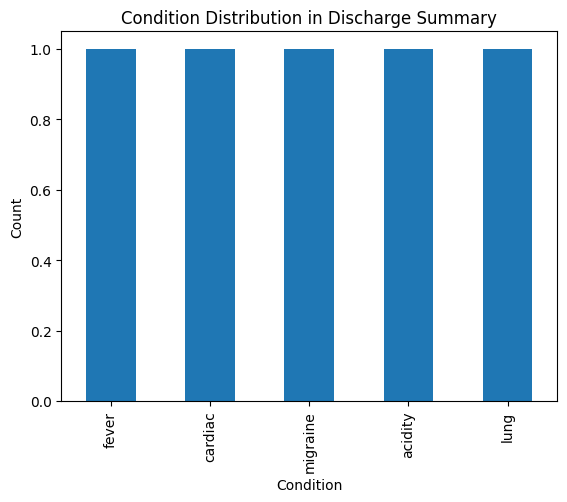

In [126]:
import matplotlib.pyplot as plt

ds_df['condition'].value_counts().plot(kind='bar')
plt.title("Condition Distribution in Discharge Summary")
plt.xlabel("Condition")
plt.ylabel("Count")
plt.show()

#Visualizes the distribution of medical conditions for better understanding of trends.

#### ADMINS

In [127]:
admin_df=admin
admin_df

,Log_id,User_id,Action,Target_entity,Timestamp,Details
0,LOG001,UD020,Checked inventory,Inventory,2026-03-21 21:00:00,Checked paracetamol stock levels
1,LOG002,UD020,Updated schedule,Doctor,2026-03-21 21:10:00,Adjusted Dr.Kumar availability
2,LOG003,UD020,Viewed patient data,Patient,2026-03-21 21:20:00,Accessed records of P001
3,LOG004,UD020,Generated report,Reports,2026-03-21 21:30:00,Created daily patient summary
4,LOG005,UD020,Updated inventory,Inventory,2026-03-21 21:40:00,Added 500 units of medicine stock


In [128]:
admin_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5 entries, 0 to 4
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Log_id         5 non-null      object
 1   User_id        5 non-null      object
 2   Action         5 non-null      object
 3   Target_entity  5 non-null      object
 4   Timestamp      5 non-null      object
 5   Details        5 non-null      object
dtypes: object(6)
memory usage: 372.0+ bytes


In [129]:
admin_df.isnull().sum()

#Verified that there are no missing values to ensure reliable administrative data.

Log_id           0
User_id          0
Action           0
Target_entity    0
Timestamp        0
Details          0
dtype: int64

In [130]:
admin_df.duplicated().sum()

#Checked for duplicate admin records to maintain data integrity and avoid redundancy.

np.int64(0)

In [131]:
admin_df.describe()

,Log_id,User_id,Action,Target_entity,Timestamp,Details
count,5,5,5,5,5,5
unique,5,1,5,4,5,5
top,LOG001,UD020,Checked inventory,Inventory,2026-03-21 21:00:00,Checked paracetamol stock levels
freq,1,5,1,2,1,1


In [132]:
admin_df['Timestamp'] = pd.to_datetime(admin_df['Timestamp'])

#Converted timestamp column into datetime format to enable time-based analysis of system activities.

In [133]:
admin_df['hour'] = admin_df['Timestamp'].dt.hour
admin_df

#Extracted hour from timestamp to analyze peak system usage times

,Log_id,User_id,Action,Target_entity,Timestamp,Details,hour
0,LOG001,UD020,Checked inventory,Inventory,2026-03-21 21:00:00,Checked paracetamol stock levels,21
1,LOG002,UD020,Updated schedule,Doctor,2026-03-21 21:10:00,Adjusted Dr.Kumar availability,21
2,LOG003,UD020,Viewed patient data,Patient,2026-03-21 21:20:00,Accessed records of P001,21
3,LOG004,UD020,Generated report,Reports,2026-03-21 21:30:00,Created daily patient summary,21
4,LOG005,UD020,Updated inventory,Inventory,2026-03-21 21:40:00,Added 500 units of medicine stock,21


In [134]:
admin_df['date'] = admin_df['Timestamp'].dt.date
admin_df

#Extracted date to analyze daily activity trends.

,Log_id,User_id,Action,Target_entity,Timestamp,Details,hour,date
0,LOG001,UD020,Checked inventory,Inventory,2026-03-21 21:00:00,Checked paracetamol stock levels,21,2026-03-21
1,LOG002,UD020,Updated schedule,Doctor,2026-03-21 21:10:00,Adjusted Dr.Kumar availability,21,2026-03-21
2,LOG003,UD020,Viewed patient data,Patient,2026-03-21 21:20:00,Accessed records of P001,21,2026-03-21
3,LOG004,UD020,Generated report,Reports,2026-03-21 21:30:00,Created daily patient summary,21,2026-03-21
4,LOG005,UD020,Updated inventory,Inventory,2026-03-21 21:40:00,Added 500 units of medicine stock,21,2026-03-21


In [135]:
admin_df['Details'] =admin_df['Details'].str.lower().str.strip()

In [136]:
def extract_activity(text):
    if "stock" in text:
        return "Inventory Check"
    elif "availability" in text:
        return "Schedule Update"
    elif "records" in text:
        return "Patient Access"
    elif "report" in text:
        return "Report Generation"
    else:
        return "Other"

admin_df['activity_type'] = admin_df['Details'].apply(extract_activity)

#Extracted meaningful categories from unstructured log details to better understand system usage patterns.

EDA

In [137]:
admin_df['Action'].value_counts()

#Shows the most frequent actions performed by admins, such as inventory updates or patient data access.

Action
Checked inventory      1
Updated schedule       1
Viewed patient data    1
Generated report       1
Updated inventory      1
Name: count, dtype: int64

In [138]:
admin_df['Target_entity'].value_counts()

Target_entity
Inventory    2
Doctor       1
Patient      1
Reports      1
Name: count, dtype: int64

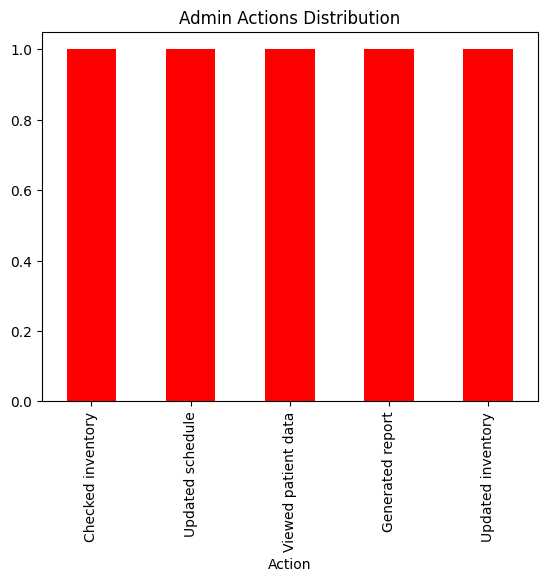

In [139]:
import matplotlib.pyplot as plt

admin_df['Action'].value_counts().plot(kind='bar',color='red')
plt.title("Admin Actions Distribution")
plt.show()

#Visual representation of admin activities helps quickly understand system usage patterns.

In [140]:
admin_df[admin_df['Action'].str.contains("Viewed patient data")]

#Helps track sensitive operations like patient data access for security and compliance.

,Log_id,User_id,Action,Target_entity,Timestamp,Details,hour,date,activity_type
2,LOG003,UD020,Viewed patient data,Patient,2026-03-21 21:20:00,accessed records of p001,21,2026-03-21,Patient Access


##### NLP

In [141]:
combined_text = pd.concat([
    mr_df['Extracted_text'],
    ds_df['Summary_text']
]).reset_index(drop=True)

combined_df = pd.DataFrame({"text": combined_text})

combined_df
#Combined medical reports and discharge summaries into a single dataset to create a unified text source for model training.


,text
0,cbc: wbc 6200 rbc 4.5m normal
1,mild infection in lungs
2,no abnormalities detected
3,high glucose level detected
4,lung inflammation observed
5,3-day observation fever treated follow-up in 5...
6,cardiac issue stabilized medication prescribed
7,migraine treated advised rest and hydration
8,acidity controlled diet changes recommended
9,lung infection treated antibiotics prescribed


In [142]:
import re
def clean_text(text):
    text = str(text).lower()

    # remove doctor names
    text = re.sub(r'dr\.\s*\w+\s*\w*', '', text)
    text = re.sub(r'general physician', '', text)
    text = re.sub(r'[^a-z0-9\s/]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

combined_df['text'] = combined_df['text'].apply(clean_text)

#Converted text to lowercase and normalized whitespace while preserving important medical patterns such as numbers and symbols.

In [143]:
keywords = {
    "migraine": ["migraine", "headache"],
    "diabetes": ["glucose", "sugar"],
    "lung": ["lung"],
    "cardiac": ["cardiac", "heart"],
    "infection": ["infection", "inflammation"],
    "fever": ["fever"],
    "acidity": ["acidity"],
    "normal": ["normal", "no abnormalities"]
}

In [144]:
def extract_condition(text):
    text = str(text).lower()
    found = []

    for condition, words in keywords.items():
        for word in words:
            if re.search(r'\b' + word + r'\b', text):
                found.append(condition)

    priority = ["migraine","diabetes","lung","cardiac","infection","fever","acidity","normal"]

    for p in priority:
        if p in found:
            return p

    return "normal"

    # Medical conditions are identified using keyword matching with regex (exact word matching).
    #Multiple matches are handled using priority logic.

In [145]:
def extract_doctor(text, condition):

    if condition == "migraine":
        return "Neurologist"
    elif condition == "diabetes":
        return "Endocrinologist"
    elif condition == "lung":
        return "Pulmonologist"
    elif condition == "cardiac":
        return "Cardiologist"
    elif condition == "acidity":
        return "Gastroenterologist"
    else:
        return "General Physician"

#Doctors are assigned based on detected condition using predefined mappings.

In [146]:
combined_df['condition'] = combined_df['text'].apply(extract_condition)

combined_df['recommended_doctor'] = combined_df.apply(
    lambda row: extract_doctor(row['text'], row['condition']),
    axis=1
)

combined_df

,text,condition,recommended_doctor
0,cbc wbc 6200 rbc 4 5m normal,normal,General Physician
1,mild infection in lungs,infection,General Physician
2,no abnormalities detected,normal,General Physician
3,high glucose level detected,diabetes,Endocrinologist
4,lung inflammation observed,lung,Pulmonologist
5,3 day observation fever treated follow up in 5...,fever,General Physician
6,cardiac issue stabilized medication prescribed,cardiac,Cardiologist
7,migraine treated advised rest and hydration,migraine,Neurologist
8,acidity controlled diet changes recommended,acidity,Gastroenterologist
9,lung infection treated antibiotics prescribed,lung,Pulmonologist


#### VECTORIZATION

In [147]:
vectorizer = CountVectorizer(ngram_range=(1,2))
X = vectorizer.fit_transform(combined_df['text'])

#Text data cannot be directly used by machine learning models. So we convert text into numerical form
#using CountVectorizer, which creates a matrix based on word frequency.


##### ML

In [148]:
model = MultinomialNB()
model.fit(X, combined_df['recommended_doctor'])

#A Multinomial Naive Bayes model is trained to predict doctor recommendations from text.

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [149]:
def predict_doctor(text):
    text = clean_text(text)
    vec = vectorizer.transform([text])
    return model.predict(vec)[0]



In [150]:
def final_prediction(text):
    text = clean_text(text)

    condition = extract_condition(text)
    doctor = extract_doctor(text, condition)

    return f"""
Condition: {condition.upper()}
Recommended Doctor: {doctor}
"""
#A function is created to:Clean input text,Convert to vector,Predict doctor.

#Due to limited dataset size, ML accuracy is low, so I relied on rule-based logic for final predictions.

In [151]:
print(final_prediction("migraine headache"))
print(final_prediction("high glucose"))
print(final_prediction("lung infection"))


Condition: MIGRAINE
Recommended Doctor: Neurologist


Condition: DIABETES
Recommended Doctor: Endocrinologist


Condition: LUNG
Recommended Doctor: Pulmonologist



In [169]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = MultinomialNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.0
                    precision    recall  f1-score   support

Gastroenterologist       0.00      0.00      0.00       1.0
 General Physician       0.00      0.00      0.00       1.0
     Pulmonologist       0.00      0.00      0.00       0.0

          accuracy                           0.00       2.0
         macro avg       0.00      0.00      0.00       2.0
      weighted avg       0.00      0.00      0.00       2.0



e:\DS\PROJECTS\FINAL PROJECT\CareConnect AI\CareConnect AI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\DS\PROJECTS\FINAL PROJECT\CareConnect AI\CareConnect AI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\DS\PROJECTS\FINAL PROJECT\CareConnect AI\CareConnect AI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this beh

In [168]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_rf = RandomForestClassifier(class_weight='balanced')
model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.5
                    precision    recall  f1-score   support

Gastroenterologist       0.00      0.00      0.00         1
 General Physician       0.50      1.00      0.67         1

          accuracy                           0.50         2
         macro avg       0.25      0.50      0.33         2
      weighted avg       0.25      0.50      0.33         2



e:\DS\PROJECTS\FINAL PROJECT\CareConnect AI\CareConnect AI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\DS\PROJECTS\FINAL PROJECT\CareConnect AI\CareConnect AI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\DS\PROJECTS\FINAL PROJECT\CareConnect AI\CareConnect AI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

In [170]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model_rf = RandomForestClassifier(class_weight='balanced')
model_rf.fit(X_train, y_train)

y_pred = model_rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

#Performance is limited due to small dataset size
#Rule-based system provides more reliable results

Accuracy: 0.5
                    precision    recall  f1-score   support

Gastroenterologist       0.00      0.00      0.00         1
 General Physician       0.50      1.00      0.67         1

          accuracy                           0.50         2
         macro avg       0.25      0.50      0.33         2
      weighted avg       0.25      0.50      0.33         2



e:\DS\PROJECTS\FINAL PROJECT\CareConnect AI\CareConnect AI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\DS\PROJECTS\FINAL PROJECT\CareConnect AI\CareConnect AI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
e:\DS\PROJECTS\FINAL PROJECT\CareConnect AI\CareConnect AI\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 

### OCR

In [ ]:
!apt-get update
!apt-get install -y tesseract-ocr
!pip install pytesseract pillow

'apt-get' is not recognized as an internal or external command,
operable program or batch file.
'apt-get' is not recognized as an internal or external command,
operable program or batch file.



[notice] A new release of pip is available: 25.0.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [156]:
import pytesseract
from PIL import Image

def extract_text_from_image(image_path):
    img = Image.open(image_path)
    text = pytesseract.image_to_string(img)
    return text

#Medical report images are converted into text using Tesseract OCR.

In [172]:
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

In [173]:
text = extract_text_from_image("medical_report.png")
print(text)

PRASHANTH rensans

MEDICAL CERTIFICATE

PATIENT NAME :PRADEEPR
AGE /SEX: 21 VEARS / MALE

Dingnose: Viral Fever
Thine to cry tat,

‘Me Pradeep R Who was uade one teatnnt fer Vl Fever in oor hop 8
for severe body pain and Voning We have aie han fake rest for |
vreek (103/203 6 160872023)

4

‘CONSULTANT CARDIOTHORACIC AND VASCULAR SURGEON
REG. NO: 70701

" 22Roeeee
eae




##### RAG

In [174]:
patient_memory = {
    "P001": "Had fever and headache last week",
    "P002": "High BP patient",
    "P003": "Diabetes patient"
}

def get_patient_history(patient_id):
    return patient_memory.get(patient_id, "No history found")

#Patient history is retrieved using a simple dictionary-based retrieval system.

In [ ]:
def chatbot_system(user_input=None, image_path=None, patient_id=None):

    if image_path:
        text = extract_text_from_image(image_path)
    else:
        text = user_input

    result = final_prediction(text)

    history = get_patient_history(patient_id) if patient_id else "No history"

    return f"""
CareConnect AI Result

{result}

Patient History:
{history}
"""

#All components are integrated:
  # *Text input OR image input
  # *NLP processing
  # *Doctor recommendation
  # *Patient history

In [ ]:
print(chatbot_system(user_input="migraine headache", patient_id="P001"))


CareConnect AI Result


Condition: MIGRAINE
Recommended Doctor: Neurologist


Patient History:
Had fever and headache last week



In [ ]:
print(chatbot_system(image_path="medical_report.png", patient_id="P002"))


CareConnect AI Result


Condition: MIGRAINE
Recommended Doctor: Neurologist


Patient History:
High BP patient



In [ ]:
import joblib

joblib.dump(model, "model.pkl")
joblib.dump(vectorizer, "vectorizer.pkl")

['vectorizer.pkl']